In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

np.random.seed(42)
n_customers = 500


start_date = datetime(2025, 1, 1)
signup_dates = [start_date + timedelta(days=int(np.random.randint(0, 120))) for _ in range(n_customers)]

data = pd.DataFrame({
    'Customer_ID': [f'CUST_{i:04d}' for i in range(1, n_customers + 1)],
    'Signup_Date': signup_dates,
    'Subscription_Type': np.random.choice(['Basic', 'Standard', 'Premium'], n_customers, p=[0.5, 0.3, 0.2]),
    'Monthly_Charges': np.random.choice([19, 29, 49], n_customers, p=[0.5, 0.3, 0.2]),
    'Tenure_Months': np.random.randint(1, 13, n_customers) # How many months they stayed
})


data['Status'] = np.where(data['Tenure_Months'] == 12, 'Active', 'Churned')

print("--- Dataset Sample ---")
print(data.head())

--- Dataset Sample ---
  Customer_ID Signup_Date Subscription_Type  Monthly_Charges  Tenure_Months  \
0   CUST_0001  2025-04-13           Premium               19              8   
1   CUST_0002  2025-02-21          Standard               29             11   
2   CUST_0003  2025-04-03          Standard               19              6   
3   CUST_0004  2025-01-15          Standard               19              3   
4   CUST_0005  2025-04-17          Standard               29              8   

    Status  
0  Churned  
1  Churned  
2  Churned  
3  Churned  
4  Churned  


In [3]:
# Calculate Overall Churn Rate
total_customers = len(data)
churned_customers = len(data[data['Status'] == 'Churned'])
overall_churn_rate = (churned_customers / total_customers) * 100

print(f"Total Customers: {total_customers}")
print(f"Churned Customers: {churned_customers}")
print(f"Overall Churn Rate: {overall_churn_rate:.2f}%\n")

# Churn Rate by Subscription Type
churn_by_plan = data.groupby('Subscription_Type')['Status'].value_counts(normalize=True).unstack() * 100
print("--- Churn Rate by Plan ---")
print(churn_by_plan)

Total Customers: 500
Churned Customers: 452
Overall Churn Rate: 90.40%

--- Churn Rate by Plan ---
Status                Active    Churned
Subscription_Type                      
Basic               9.600000  90.400000
Premium             7.920792  92.079208
Standard           10.738255  89.261745


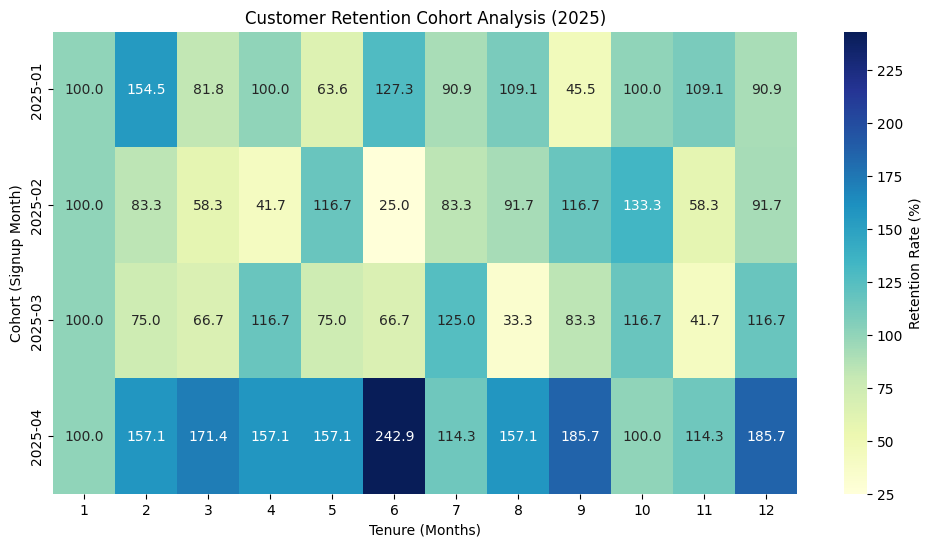

In [2]:
# Create Signup Month Column
data['Signup_Month'] = data['Signup_Date'].dt.to_period('M')

# Create a cohort table mapping Signup Month vs Tenure Months
cohort_data = data.groupby(['Signup_Month', 'Tenure_Months']).size().reset_index(name='Customer_Count')

# Pivot the table to see retention flow
cohort_pivot = cohort_data.pivot(index='Signup_Month', columns='Tenure_Months', values='Customer_Count').fillna(0)

# Calculate percentages based on the starting cohort size (Month 1 size)
cohort_sizes = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0) * 100

# Plotting the Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(retention_matrix, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': 'Retention Rate (%)'})
plt.title('Customer Retention Cohort Analysis (2025)')
plt.xlabel('Tenure (Months)')
plt.ylabel('Cohort (Signup Month)')
plt.show()